### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

### Reading Dataset

In [2]:
data = pd.read_csv("Spam Detection .csv")
data


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [3]:
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
data.shape

(4601, 58)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

### Cleaning Dataset

In [6]:
print(f"Duplicate Values: {data.duplicated().sum()}")
data = data.drop_duplicates().reset_index(drop=True)

data.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Missing values:")
print(data.isnull().sum())

data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

# data.columns

Duplicate Values: 391
Missing values:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
wo

### Checking Class Distribution

spam
0    2531
1    1679
Name: count, dtype: int64
spam
0    0.601188
1    0.398812
Name: proportion, dtype: float64


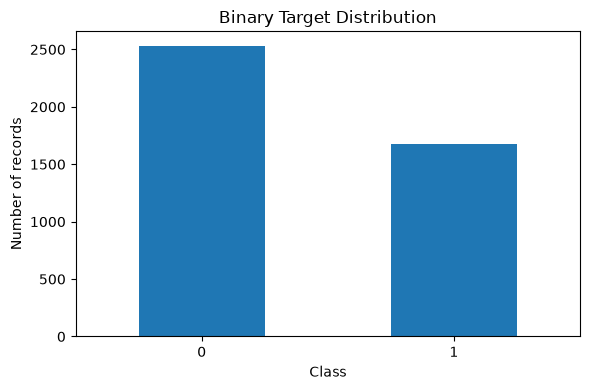

In [7]:
print(data["spam"].value_counts())
print(data["spam"].value_counts(normalize=True))

label_count = data["spam"].value_counts()
label_count

plt.figure(figsize=(6, 4))
label_count.plot(kind="bar")
plt.ylabel("Number of records")
plt.xlabel("Class")
plt.title("Binary Target Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Features Separation

In [8]:
X = data.drop(columns=["spam"])
y = data["spam"]

print(X.dtypes)

X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna()

y = y.loc[X.index]

class_names = ["Not Spam", "Spam"]

print("Classes:")
print("0 = Not Spam")
print("1 = Spam")

word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
word_freq_hpl                 float64
word_freq_ge

#### Splitting Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Scaling Data

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# print(X_train_scaled.shape)

### Dimentionality Reduction with PCA

#### Checking Number of PCA components required

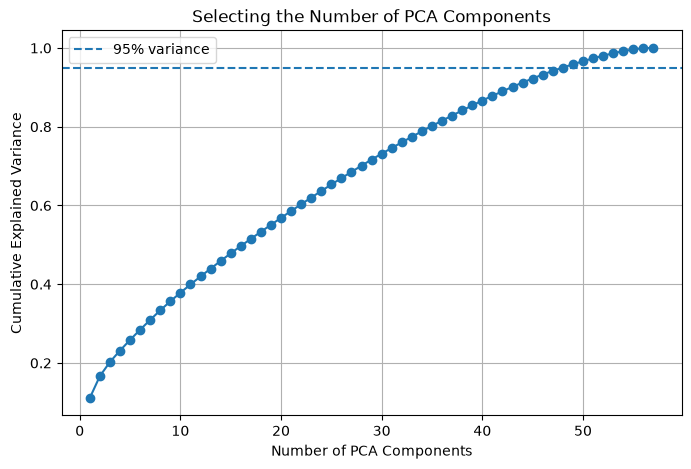

In [11]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_check = PCA()

pca_check.fit(X_train_scaled)

cumulative_variance = np.cumsum(
    pca_check.explained_variance_ratio_
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Selecting the Number of PCA Components")
plt.legend()
plt.grid()
plt.show()

#### Apply using 95% Variance

In [12]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print(
    "Original dimensions:",
    X_train_scaled.shape
)

print(
    "Reduced dimensions:",
    X_train_pca.shape
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original dimensions: (3368, 57)
Reduced dimensions: (3368, 48)
Total explained variance: 0.9504500037477235


# Supervised

## K Nearest Neighbours 

### KNN Pipline

In [13]:
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("knn", KNeighborsClassifier())
])

### Defining Cross-Validation 

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parameter_grid = {
    "knn__n_neighbors": list(range(1, 22, 2)), # Validating for neighbours 1 - 22
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

### Running Gridsearch

In [15]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X_train_pca, y_train)

Fitting 5 folds for each of 44 candidates, totalling 220 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [1, 3, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``

### Printing best KNN Parameters

In [16]:
print("Best parameters:", grid_search.best_params_)
print(
    "Best cross-validation accuracy:",
    grid_search.best_score_
)

results = pd.DataFrame(grid_search.cv_results_)

result_table = results[
    [
        "param_knn__n_neighbors",
        "mean_train_score",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
)

# print(result_table)

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best cross-validation accuracy: 0.904103597426819


### Results

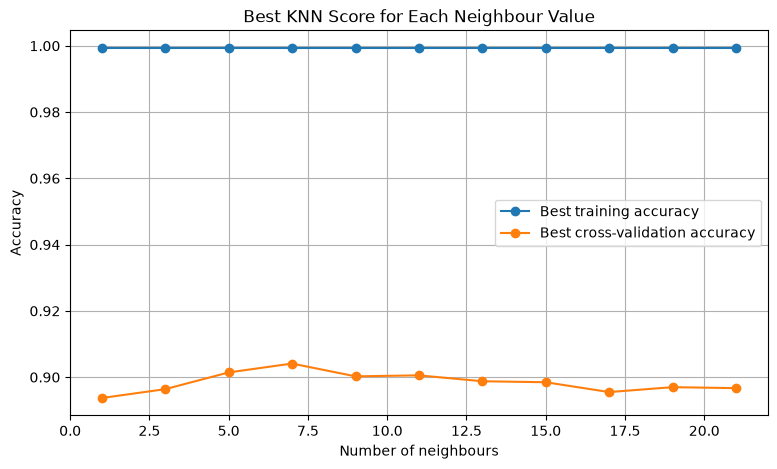

In [17]:
plot_results = (
    results.groupby("param_knn__n_neighbors", as_index=False)
    .agg(
        mean_train_score=("mean_train_score", "max"),
        mean_test_score=("mean_test_score", "max")
    )
    .sort_values("param_knn__n_neighbors")
)

plt.figure(figsize=(9, 5))

plt.plot(
    plot_results["param_knn__n_neighbors"].astype(int),
    plot_results["mean_train_score"],
    marker="o",
    label="Best training accuracy"
)

plt.plot(
    plot_results["param_knn__n_neighbors"].astype(int),
    plot_results["mean_test_score"],
    marker="o",
    label="Best cross-validation accuracy"
)

plt.xlabel("Number of neighbours")
plt.ylabel("Accuracy")
plt.title("Best KNN Score for Each Neighbour Value")
plt.legend()
plt.grid()
plt.show()

### Function for Checking Overfitting and Underfitting

In [18]:
def check_classifier_fit(modelf, Xf_train, yf_train, Xf_evaluation, yf_evaluation, model_namef="Model", gap_thresholdf=0.05, low_score_thresholdf=0.70
):
    """
    Checks for possible overfitting or underfitting.

    Parameters
    ----------
    model:
        Already-fitted sklearn model or pipeline.

    X_train, y_train:
        Training data used by the fitted model.

    X_evaluation, y_evaluation:
        Validation or test data.

    gap_threshold:
        Maximum acceptable difference between training
        and evaluation F1-scores.

    low_score_threshold:
        Scores below this value may indicate underfitting.
    """

    train_predictions = modelf.predict(Xf_train)
    evaluation_predictions = modelf.predict(Xf_evaluation)

    train_accuracy = accuracy_score(yf_train, train_predictions)
    evaluation_accuracy = accuracy_score(yf_evaluation, evaluation_predictions)
    train_precision = precision_score(yf_train, train_predictions, zero_division=0)
    evaluation_precision = precision_score(yf_evaluation, evaluation_predictions, zero_division=0)
    train_recall = recall_score(yf_train, train_predictions, zero_division=0)
    evaluation_recall = recall_score(yf_evaluation, evaluation_predictions, zero_division=0)
    train_f1 = f1_score(yf_train, train_predictions, zero_division=0)
    evaluation_f1 = f1_score(yf_evaluation, evaluation_predictions, zero_division=0)
    f1_gap = train_f1 - evaluation_f1

    if (
        train_f1 < low_score_thresholdf
        and evaluation_f1 < low_score_thresholdf
    ):
        diagnosis = "Possible underfitting"

    elif f1_gap > gap_thresholdf:
        diagnosis = "Possible overfitting"

    elif evaluation_f1 > train_f1 + gap_thresholdf:
        diagnosis = (
            "Evaluation score unexpectedly exceeds training score; "
            "check preprocessing or data leakage"
        )

    else:
        diagnosis = "Good generalisation"

    results = pd.DataFrame({
        "Model": [model_namef],
        "Train Accuracy": [train_accuracy],
        "Evaluation Accuracy": [evaluation_accuracy],
        "Train Precision": [train_precision],
        "Evaluation Precision": [evaluation_precision],
        "Train Recall": [train_recall],
        "Evaluation Recall": [evaluation_recall],
        "Train F1": [train_f1],
        "Evaluation F1": [evaluation_f1],
        "F1 Difference": [f1_gap],
        "Diagnosis": [diagnosis]
    })

    return results.round(4)

### Checking for Overfitting and Underfitting

In [19]:
best_knn = grid_search.best_estimator_
best_index = grid_search.best_index_

best_train_accuracy = results.loc[
    best_index,
    "mean_train_score"
]

best_validation_accuracy = results.loc[
    best_index,
    "mean_test_score"
]

check_classifier_fit(best_knn, X_train_pca, y_train, X_test_pca, y_test, "KNN")

,Model,Train Accuracy,Evaluation Accuracy,Train Precision,Evaluation Precision,Train Recall,Evaluation Recall,Train F1,Evaluation F1,F1 Difference,Diagnosis
0,KNN,0.9991,0.9086,1.0,0.8648,0.9978,0.9137,0.9989,0.8886,0.1103,Possible overfitting


### KPIs Function

In [20]:
def KPIs(ys_test, ys_pred, y_prob, model):
    class_names = ["Not Spam", "Spam"]
    print(
        model + " test accuracy:",
        accuracy_score(
            ys_test,
            ys_pred
        )
    )

    print(
        classification_report(
            ys_test,
            ys_pred,
            labels=[0, 1],
            target_names=class_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        ys_test,
        ys_pred,
        labels=[0, 1]
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot()
    plt.title(model + " Confusion Matrix")
    plt.show()

    auc = roc_auc_score(
        ys_test,
        y_prob
    )

    print(model + " ROC-AUC:", auc)

    RocCurveDisplay.from_predictions(
        ys_test,
        y_prob
    )

    plt.title(model + " ROC Curve")
    plt.show()

### Prediction and KPIs

KNN test accuracy: 0.9085510688836105
              precision    recall  f1-score   support

    Not Spam       0.94      0.91      0.92       506
        Spam       0.86      0.91      0.89       336

    accuracy                           0.91       842
   macro avg       0.90      0.91      0.91       842
weighted avg       0.91      0.91      0.91       842



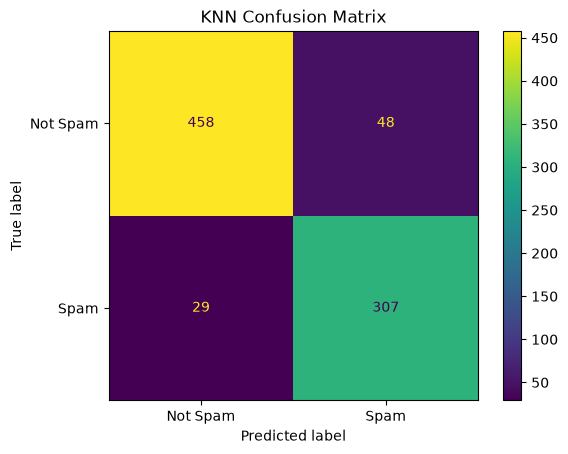

KNN ROC-AUC: 0.9617388951628081


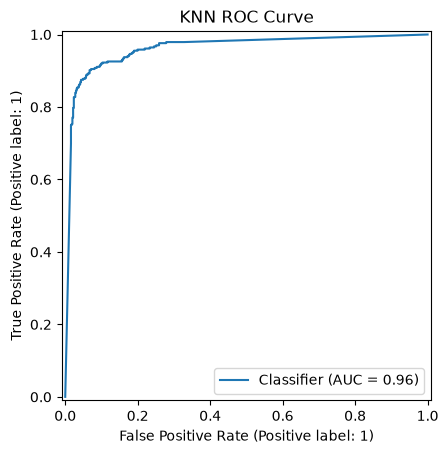

In [21]:

y_test_pred = best_knn.predict(X_test_pca)
y_knn_prob = grid_search.predict_proba(X_test_pca)[:, 1]

KPIs(y_test, y_test_pred, y_knn_prob, "KNN")


## Logistic Regression

### Plot the Graph

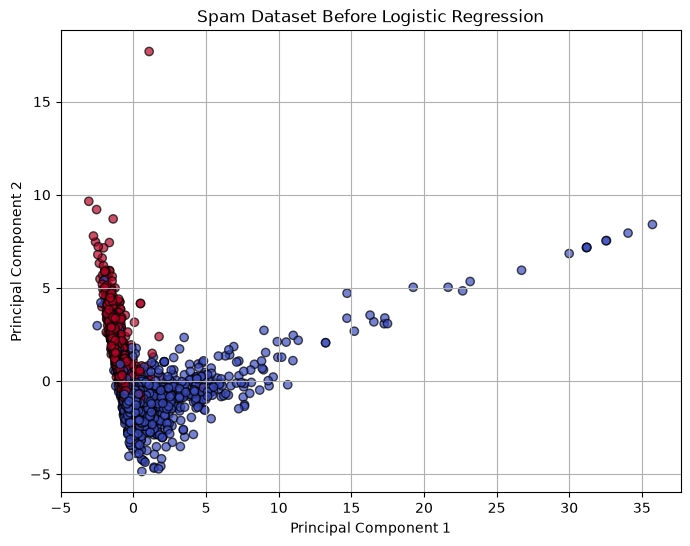

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="k",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Spam Dataset Before Logistic Regression")
plt.grid(True)
plt.show()

### Preparing dataset for Logistic Regression

In [23]:
logistic_pipeline = Pipeline([
    ("pca", PCA(n_components=2, random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ("logistic", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

### Hyper Parameters

In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_parameter_grid = [
    {
        "logistic__solver": ["liblinear"],
        "logistic__l1_ratio": [0.0, 1.0],
        "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "logistic__solver": ["lbfgs", "newton-cg", "newton-cholesky"],
        "logistic__l1_ratio": [0.0],
        "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "logistic__solver": ["saga"],
        "logistic__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
        "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
]


### Logistic Fit

In [25]:
grid_search_logistic = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_parameter_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search_logistic.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'logistic__C': [0.001, 0.01, ...], 'logistic__l1_ratio': [0.0, 1.0], 'logistic__solver': ['liblinear']}, {'logistic__C': [0.001, 0.01, ...], 'logistic__l1_ratio': [0.0], 'logistic__solver': ['lbfgs', 'newton-cg', ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function which

### Best Parameters

In [26]:
best_logistic = grid_search_logistic.best_estimator_

print(grid_search_logistic.best_params_)
print(grid_search_logistic.best_score_)


logistic_results = pd.DataFrame(
    grid_search_logistic.cv_results_
)

{'logistic__C': 0.1, 'logistic__l1_ratio': 1.0, 'logistic__solver': 'liblinear'}
0.8347026228574521


### Plot Before Decision Boundry

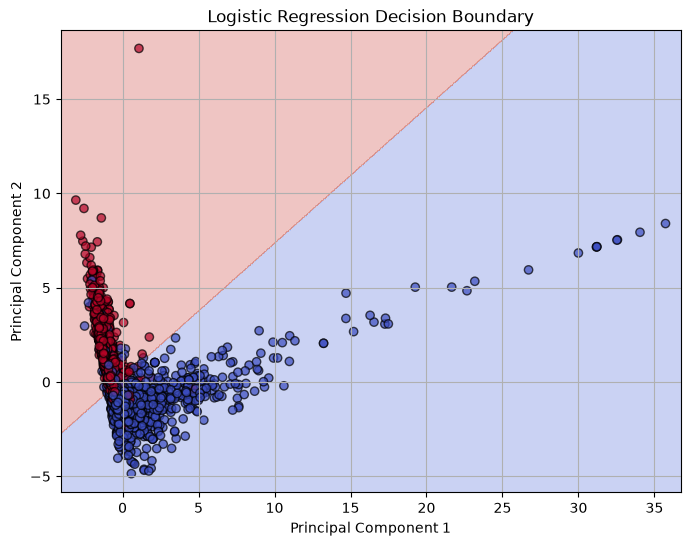

In [27]:
fitted_pca = best_logistic.named_steps["pca"]
fitted_logistic = best_logistic.named_steps["logistic"]

X_train_2d = fitted_pca.transform(X_train_scaled)
X_test_2d = fitted_pca.transform(X_test_scaled)

x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1

y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = fitted_logistic.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap="coolwarm"
)

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    cmap="coolwarm",
    edgecolors="black",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Logistic Regression Decision Boundary")
plt.grid(True)
plt.show()

In [28]:
fitted_logistic = (
    grid_search_logistic
    .best_estimator_
    .named_steps["logistic"]
)

check_classifier_fit(fitted_logistic, X_train_2d, y_train, X_test_2d, y_test, "Logistic Regression", )

,Model,Train Accuracy,Evaluation Accuracy,Train Precision,Evaluation Precision,Train Recall,Evaluation Recall,Train F1,Evaluation F1,F1 Difference,Diagnosis
0,Logistic Regression,0.8679,0.8943,0.8341,0.8601,0.8347,0.878,0.8344,0.8689,-0.0345,Good generalisation


### KPIs

Training F1-score: 0.8355257204697295
Validation F1-score: 0.8347026228574521
Difference: 0.0008230976122773903
Logistic Regression test accuracy: 0.8942992874109263
              precision    recall  f1-score   support

    Not Spam       0.92      0.91      0.91       506
        Spam       0.86      0.88      0.87       336

    accuracy                           0.89       842
   macro avg       0.89      0.89      0.89       842
weighted avg       0.89      0.89      0.89       842



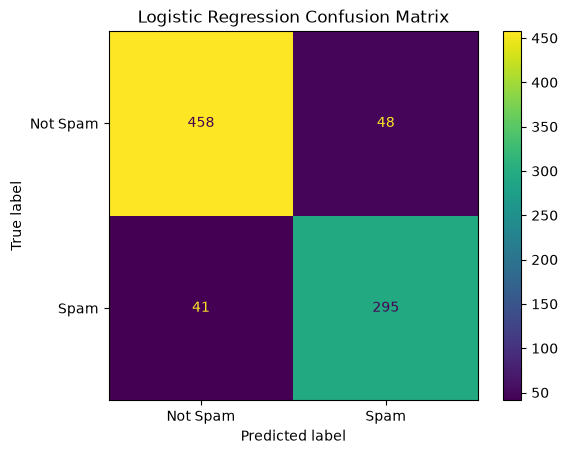

Logistic Regression ROC-AUC: 0.9500517598343685


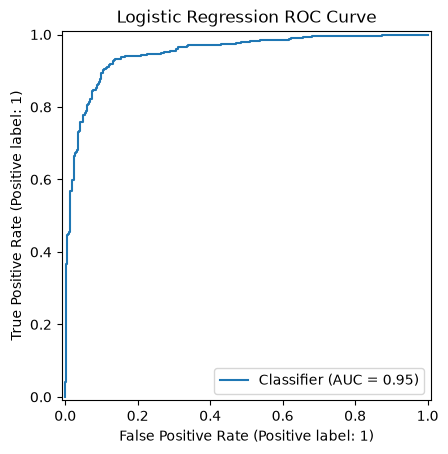

In [29]:
logistic_best_index = grid_search_logistic.best_index_
training_score = logistic_results.loc[ logistic_best_index, "mean_train_score"]
validation_score = logistic_results.loc[logistic_best_index, "mean_test_score"]

print("Training F1-score:", training_score)
print("Validation F1-score:", validation_score)
print("Difference:", training_score - validation_score)

best_logistic_model = (grid_search_logistic.best_estimator_)
y_pred_logistic = (best_logistic_model.predict(X_test_scaled))
y_prob_logistic = best_logistic_model.predict_proba(X_test_scaled)[:, 1]

KPIs(y_test, y_pred_logistic, y_prob_logistic, "Logistic Regression")

## Random Forest

### Creating Pipeline

In [30]:
from sklearn.ensemble import RandomForestClassifier

rfc_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rfc", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

### Parameters and Training

In [31]:
random_forest_parameters = {
    "rfc__n_estimators": [100, 200, 300, 500],
    "rfc__max_depth": [None, 5, 10, 20, 30],
    "rfc__min_samples_split": [2, 5, 10],
    "rfc__min_samples_leaf": [1, 2, 4],
    "rfc__max_features": ["sqrt", "log2"],
    "rfc__class_weight": [None, "balanced"]
}

random_forest_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_random_forest = GridSearchCV(
    estimator=rfc_pipeline,
    param_grid=random_forest_parameters,
    scoring="f1",
    cv=random_forest_cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
    refit=True
)

grid_search_random_forest.fit(
    X_train_scaled,
    y_train
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rfc__class_weight': [None, 'balanced'], 'rfc__max_depth': [None, 5, ...], 'rfc__max_features': ['sqrt', 'log2'], 'rfc__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatca

### Best Parameters

In [32]:
print("Best Random Forest parameters:")
print(grid_search_random_forest.best_params_)

print(
    "Best validation F1-score:",
    grid_search_random_forest.best_score_
)

Best Random Forest parameters:
{'rfc__class_weight': None, 'rfc__max_depth': 30, 'rfc__max_features': 'sqrt', 'rfc__min_samples_leaf': 1, 'rfc__min_samples_split': 2, 'rfc__n_estimators': 200}
Best validation F1-score: 0.9377803313492263


### Best Scores

In [33]:
random_forest_results = pd.DataFrame(
    grid_search_random_forest.cv_results_
)

best_random_forest = (
    grid_search_random_forest.best_estimator_
)


best_index = grid_search_random_forest.best_index_

training_f1 = random_forest_results.loc[
    best_index,
    "mean_train_score"
]

validation_f1 = random_forest_results.loc[
    best_index,
    "mean_test_score"
]

print("Training F1-score:", training_f1)
print("Validation F1-score:", validation_f1)
print(
    "Difference:",
    training_f1 - validation_f1
)

Training F1-score: 0.9987893531617452
Validation F1-score: 0.9377803313492263
Difference: 0.06100902181251888


### Top 10 Features

     param_rfc__n_estimators param_rfc__max_depth  \
289                      200                   30   
37                       200                 None   
255                      500                   20   
648                      100                   30   
41                       200                 None   
2                        300                 None   
254                      300                   20   
397                      200                 None   
45                       200                 None   
39                       500                 None   

     param_rfc__min_samples_split  param_rfc__min_samples_leaf  \
289                             2                            1   
37                              2                            1   
255                             2                            1   
648                             2                            1   
41                              5                            1   
2                   

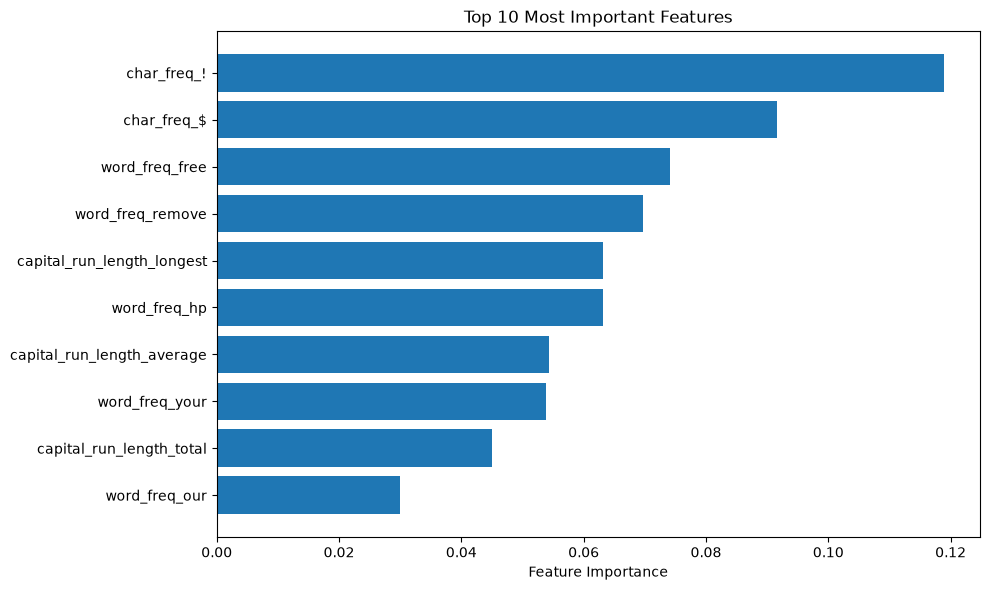

In [34]:
top10 = (
    random_forest_results
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

top10 = top10[
    [
        "param_rfc__n_estimators",
        "param_rfc__max_depth",
        "param_rfc__min_samples_split",
        "param_rfc__min_samples_leaf",
        "mean_test_score"
    ]
]

print(top10)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_random_forest.named_steps["rfc"].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()

In [35]:
check_classifier_fit(best_random_forest, X_train, y_train, X_test, y_test, "Random Forest",)

f:\BCU\Machine Learning\Project\.venv-tf\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
f:\BCU\Machine Learning\Project\.venv-tf\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Model,Train Accuracy,Evaluation Accuracy,Train Precision,Evaluation Precision,Train Recall,Evaluation Recall,Train F1,Evaluation F1,F1 Difference,Diagnosis
0,Random Forest,0.6012,0.601,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Possible underfitting


### KPIs

Random Forest test accuracy: 0.9406175771971497
              precision    recall  f1-score   support

    Not Spam       0.95      0.95      0.95       506
        Spam       0.92      0.93      0.93       336

    accuracy                           0.94       842
   macro avg       0.94      0.94      0.94       842
weighted avg       0.94      0.94      0.94       842



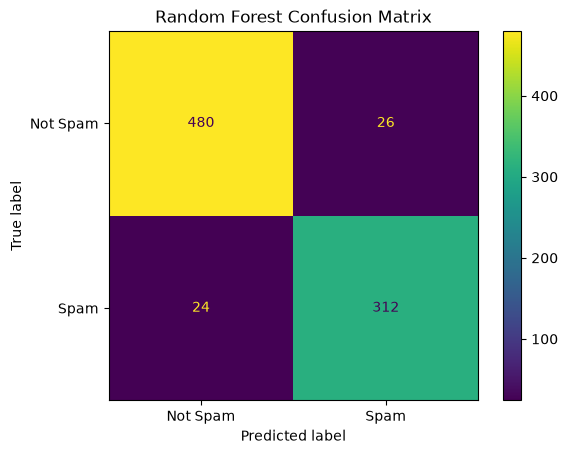

Random Forest ROC-AUC: 0.9896980284208546


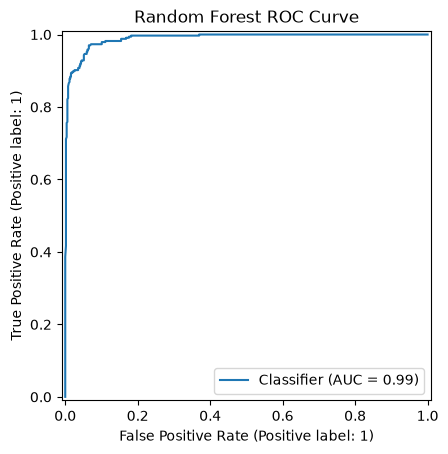

In [36]:

y_pred_random_forest = (
    best_random_forest.predict(X_test_scaled)
)

y_probability_random_forest = (
    best_random_forest.predict_proba(
        X_test_scaled
    )[:, 1]
)

KPIs(y_test, y_pred_random_forest, y_probability_random_forest, "Random Forest")

Rows after filtering: 8
   param_rfc__n_estimators  mean_test_score
0                      100         0.937034
1                      200         0.937780
2                      300         0.936906
3                      500         0.937148


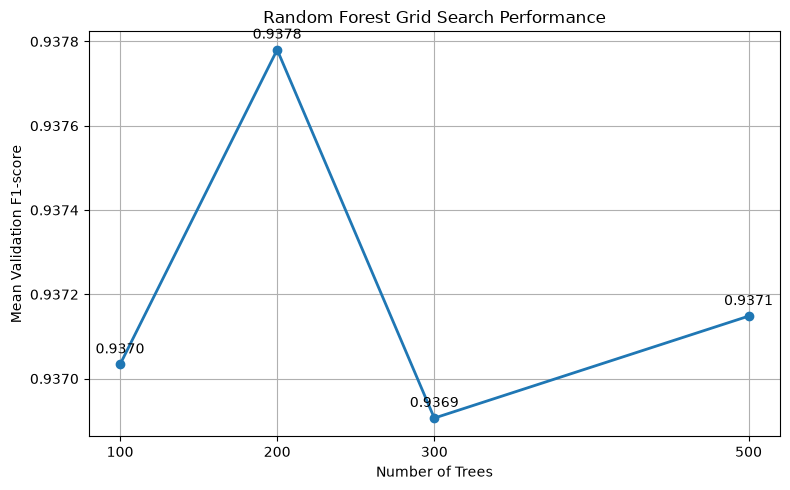

In [37]:
best_params = grid_search_random_forest.best_params_

rf_plot_data = random_forest_results.copy()

rf_plot_data = rf_plot_data[
    rf_plot_data["param_rfc__max_depth"].astype(str)
    == str(best_params["rfc__max_depth"])
]

rf_plot_data = rf_plot_data[
    rf_plot_data["param_rfc__min_samples_leaf"].astype(str)
    == str(best_params["rfc__min_samples_leaf"])
]

rf_plot_data = rf_plot_data[
    rf_plot_data["param_rfc__min_samples_split"].astype(str)
    == str(best_params["rfc__min_samples_split"])
]

best_class_weight = best_params["rfc__class_weight"]

if best_class_weight is None:
    rf_plot_data = rf_plot_data[
        rf_plot_data["param_rfc__class_weight"].isna()
        |
        (
            rf_plot_data["param_rfc__class_weight"]
            .astype(str)
            .isin(["None", "nan"])
        )
    ]
else:
    rf_plot_data = rf_plot_data[
        rf_plot_data["param_rfc__class_weight"].astype(str)
        == str(best_class_weight)
    ]

print("Rows after filtering:", rf_plot_data.shape[0])

rf_plot_summary = (
    random_forest_results
    .groupby(
        "param_rfc__n_estimators",
        as_index=False
    )["mean_test_score"]
    .max()
    .sort_values("param_rfc__n_estimators")
)

print(rf_plot_summary)

if rf_plot_summary.empty:
    print("No matching GridSearchCV results were found.")
else:
    plt.figure(figsize=(8, 5))

    plt.plot(
        rf_plot_summary["param_rfc__n_estimators"].astype(int),
        rf_plot_summary["mean_test_score"].astype(float),
        marker="o",
        linewidth=2
    )

    for x, y in zip(
        rf_plot_summary["param_rfc__n_estimators"].astype(int),
        rf_plot_summary["mean_test_score"].astype(float)
    ):
        plt.annotate(
            f"{y:.4f}",
            xy=(x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center"
        )

    plt.xlabel("Number of Trees")
    plt.ylabel("Mean Validation F1-score")
    plt.title("Random Forest Grid Search Performance")
    plt.xticks(
        rf_plot_summary["param_rfc__n_estimators"].astype(int)
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Top 10 Random Forest Configurations

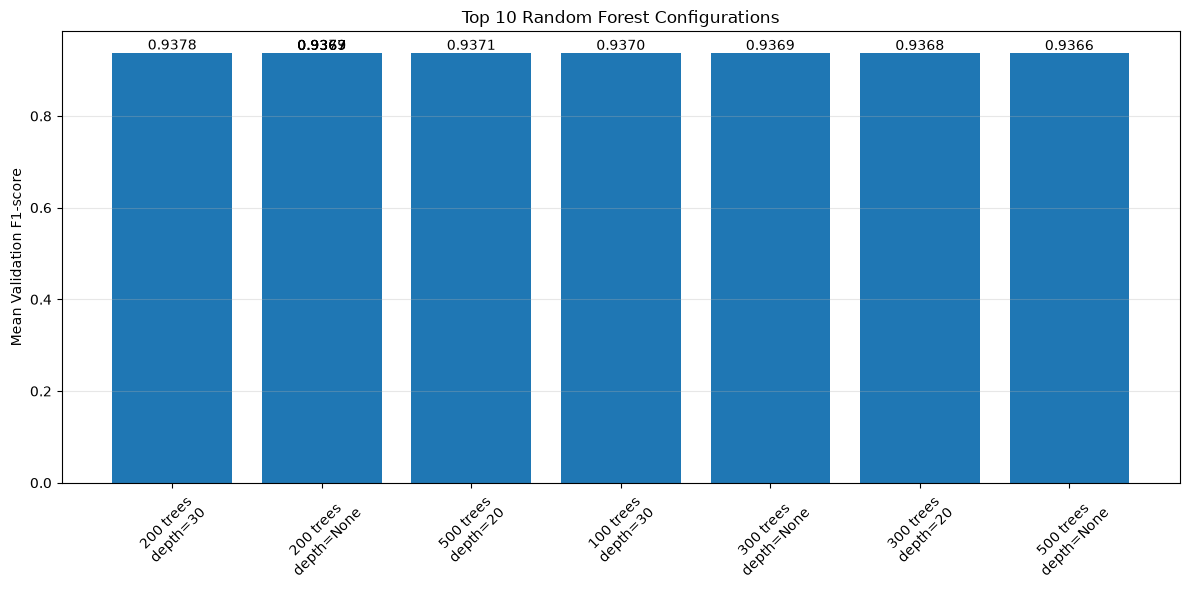

In [38]:
labels = [
    f"{row['param_rfc__n_estimators']} trees\n"
    f"depth={row['param_rfc__max_depth']}"
    for _, row in top10.iterrows()
]

plt.figure(figsize=(12,6))

bars = plt.bar(
    labels,
    top10["mean_test_score"]
)

plt.bar_label(
    bars,
    fmt="%.4f"
)

plt.ylabel("Mean Validation F1-score")
plt.title("Top 10 Random Forest Configurations")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Unsupervised

### Gausian Mixture Model

#### Creating Pipeline

In [39]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import KFold
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    ConfusionMatrixDisplay,
    normalized_mutual_info_score,
)

gmm_pipeline = Pipeline([
    ("gmm", GaussianMixture(random_state=42))
])

#### Creating Silhoute Scoring Function

In [40]:
from sklearn.metrics import silhouette_score

def gmm_silhouette_scorer(estimator, X, y=None):

    labels = estimator.predict(X)

    if len(np.unique(labels)) < 2:
        return -1

    return silhouette_score(
        X,
        labels
    )

In [41]:
# component_range = range(1, 16)

# covariance_types = [
#     "full",
#     "tied",
#     "diag",
#     "spherical"
# ]

# gmm_results = []

# for covariance in covariance_types:
#     for n in component_range:

#         gmm = GaussianMixture(
#             n_components=n,
#             covariance_type=covariance,
#             random_state=42,
#             max_iter=500,
#             n_init=5,
#             reg_covar=1e-6
#         )

#         gmm.fit(X_train_pca)

#         gmm_results.append({
#             "n_components": n,
#             "covariance_type": covariance,
#             "AIC": gmm.aic(X_train_pca),
#             "BIC": gmm.bic(X_train_pca),
#             "converged": gmm.converged_,
#             "iterations": gmm.n_iter_
#         })

# gmm_results = pd.DataFrame(gmm_results)

In [42]:
# best_bic = gmm_results.loc[
#     gmm_results["BIC"].idxmin()
# ]

# best_aic = gmm_results.loc[
#     gmm_results["AIC"].idxmin()
# ]

# print("Best according to BIC:")
# print(best_bic)

# print("\nBest according to AIC:")
# print(best_aic)

# # print(best_bic['n_components'].item())

# for covariance in covariance_types:

#     subset = gmm_results[
#         gmm_results["covariance_type"] == covariance
#     ]

#     plt.plot(
#         subset["n_components"],
#         subset["BIC"],
#         marker="o",
#         label=covariance
#     )

# plt.xlabel("Number of Components")
# plt.ylabel("BIC")
# plt.title("GMM Component and Covariance Selection")
# plt.xticks(list(component_range))
# plt.legend(title="Covariance Type")
# plt.grid(True)
# plt.show()

#### Training

In [43]:
# parameter_grid = {
#     "gmm__n_components": [best_bic['n_components']],
#     "gmm__covariance_type": [best_bic['covariance_type']]
# }

parameter_grid = {
    "gmm__n_components": list(range(2,16)),
    "gmm__covariance_type": ["full", "tied", "diag", "spherical"]
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_gmm = GridSearchCV(
    estimator=gmm_pipeline,
    param_grid=parameter_grid,
    scoring=gmm_silhouette_scorer,
    cv=cv,
    n_jobs=-1,
)

grid_search_gmm.fit(X_train_pca)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gmm__covariance_type': ['full', 'tied', ...], 'gmm__n_components': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function gmm...002708B1D7600>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",

#### Best Parameters

In [44]:
gmm_res = pd.DataFrame(grid_search_gmm.cv_results_)[['param_gmm__n_components', 'param_gmm__covariance_type', 'mean_test_score', 'rank_test_score']]


# print("Best Parameters:")
# print(grid_search_gmm.best_params_)
# print("Best Silhouette Score:",grid_search_gmm.best_score_)

# results = pd.DataFrame(
#     grid_search_gmm.cv_results_
# )

best_gmm = grid_search_gmm.best_estimator_
gmm = best_gmm.named_steps["gmm"]
gmm_res.sort_values('rank_test_score').head()

# results[["param_gmm__n_components", "param_gmm__covariance_type", "mean_test_score", "std_test_score"]]

,param_gmm__n_components,param_gmm__covariance_type,mean_test_score,rank_test_score
15,3,tied,0.303570,1
16,4,tied,0.301090,2
17,5,tied,0.218328,3
25,13,tied,0.181261,4
24,12,tied,0.178853,5


#### Covariance Type Vs Sihoutte Score Graph

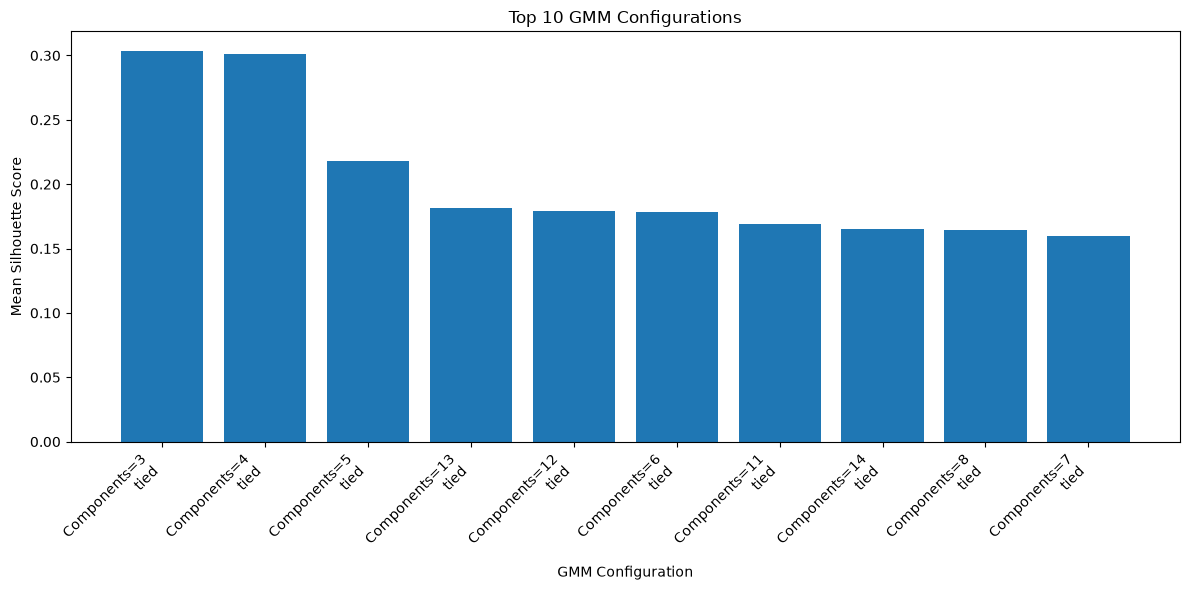

In [45]:
gmm_results2 = pd.DataFrame(
    grid_search_gmm.cv_results_
)

gmm_results2["Parameters"] = (
    "Components=" +
    gmm_results2["param_gmm__n_components"].astype(str) +
    "\n" +
    gmm_results2["param_gmm__covariance_type"].astype(str)
)

gmm_results2 = gmm_results2.sort_values(
    by="mean_test_score",
    ascending=False
)

top_gmm_results = (
    gmm_results2
    .sort_values(
        by="mean_test_score",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_gmm_results["Parameters"],
    top_gmm_results["mean_test_score"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("Mean Silhouette Score")
plt.xlabel("GMM Configuration")
plt.title("Top 10 GMM Configurations")

plt.tight_layout()
plt.show()

#### Graph of Spam Dataset before Clustering

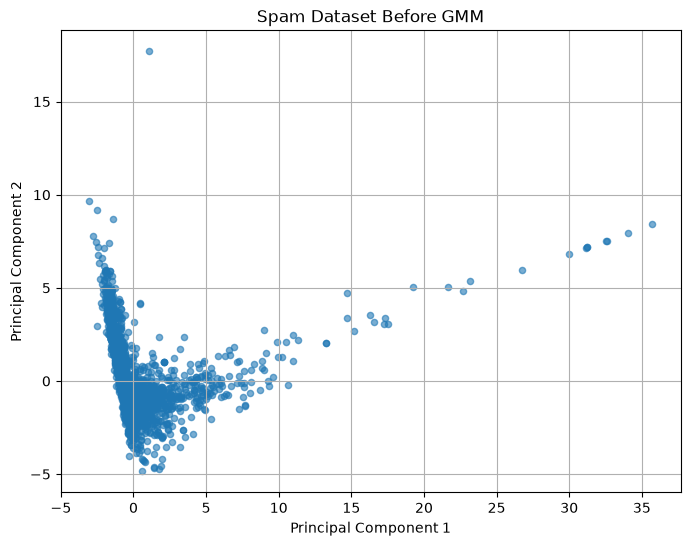

In [46]:
from sklearn.decomposition import PCA

train_clusters = gmm.predict(
    X_train_pca
)

test_clusters = gmm.predict(
    X_test_pca
)

plot_pca = PCA(
    n_components=2,
    random_state=42
)

X_train_plot = plot_pca.fit_transform(
    X_train_pca
)

X_test_plot = plot_pca.transform(
    X_test_pca
)

plt.figure(figsize=(8,6))
plt.scatter(
    X_train_plot[:,0],
    X_train_plot[:,1],
    s=20,
    alpha=0.6
)
plt.title("Spam Dataset Before GMM")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

#### Graph of Spam Dataset After Clustering

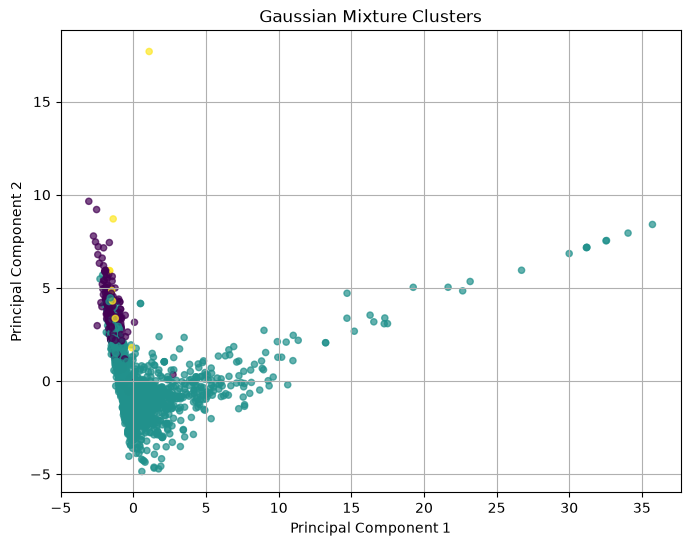

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_plot[:,0],
    X_train_plot[:,1],
    c=train_clusters,
    s=20,
    alpha=0.7,
    cmap="viridis"
)

plt.title("Gaussian Mixture Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

In [48]:
# check_classifier_fit(best_gmm, X_train_pca, y_train, X_test_pca, y_test, "GMM")

### KPIs

Silhouette Score: 0.23616464697134606
Adjusted Rand Index: 0.1279066743231765
Normalized Mutual Information: 0.16552556759161915
GMM test accuracy: 0.6947743467933492
              precision    recall  f1-score   support

    Not Spam       0.66      0.99      0.80       506
        Spam       0.96      0.24      0.39       336

    accuracy                           0.69       842
   macro avg       0.81      0.62      0.59       842
weighted avg       0.78      0.69      0.63       842



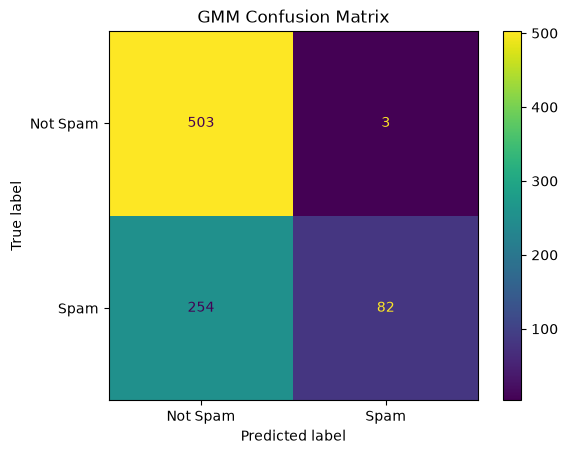

GMM ROC-AUC: 0.18290631469979296


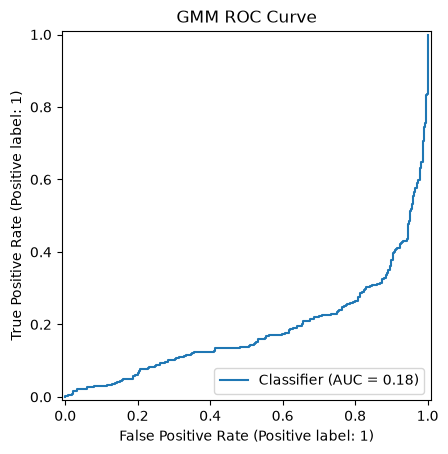

In [49]:
unique, counts = np.unique(
    train_clusters,
    return_counts=True
)

cluster_summary = pd.DataFrame({
    "Cluster": unique,
    "Samples": counts
})

gmm_silhouette_score =  silhouette_score(X_train_pca, train_clusters)
print("Silhouette Score:", gmm_silhouette_score)
mapping = {}

y_train_array = np.asarray(
    y_train
)

for cluster in np.unique(train_clusters):
    indices = np.where(train_clusters == cluster)[0]
    majority = np.bincount(y_train_array[indices]).argmax()
    mapping[cluster] = majority

y_pred_gmm = np.array([mapping[c] for c in test_clusters])

y_probability_gmm = (
    best_gmm.predict_proba(
        X_test_pca
    )[:, 1]
)

gmm_ari = adjusted_rand_score(y_test, test_clusters)
print("Adjusted Rand Index:", gmm_ari)

gmm_nmi = normalized_mutual_info_score(y_test, test_clusters)
print("Normalized Mutual Information:", gmm_nmi)

KPIs(y_test, y_pred_gmm, y_probability_gmm, "GMM")

## DBSCAN

In [98]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def dbscan_scorer(estimator, X, y=None):

    labels = estimator.fit_predict(X)

    non_noise = labels != -1
    clusters = np.unique(labels[non_noise])

    # Invalid clustering
    if len(clusters) < 2:
        return -1

    if non_noise.sum() <= len(clusters):
        return -1

    silhouette = silhouette_score(
        X[non_noise],
        labels[non_noise]
    )

    coverage = np.mean(non_noise)

    # Penalise solutions that classify
    # most samples as noise
    score = silhouette * coverage

    return score

### Hyper Parameters Calculation

In [ ]:
dbscan_parameters = {
    "eps": np.arange(0.5, 5.1, 0.25),
    "min_samples": [3, 5, 7, 10, 15, 20, 25, 30]
}

dbscan_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [106]:
grid_search_dbscan = GridSearchCV(
    estimator=DBSCAN(),
    param_grid=dbscan_parameters,
    scoring=dbscan_scorer,
    cv=dbscan_cv,
    n_jobs=-1
)

grid_search_dbscan.fit(X_train_pca)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DBSCAN()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'eps': array([0.5 , ..., 4.75, 5. ]), 'min_samples': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function dbs...00271064619E0>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [107]:
best_dbscan = grid_search_dbscan.best_estimator_
best_clusters = best_dbscan.fit_predict(X_train_pca)

print(
    "Best Parameters:",
    grid_search_dbscan.best_params_
)

print(
    "Best CV Silhouette:",
    grid_search_dbscan.best_score_
)

print(
    "Number of clusters:",
    len(set(best_clusters) - {-1})
)

labels = best_dbscan.labels_
n_clustered = np.sum(labels >= 0)
coverage_percentage = (n_clustered / len(labels)) * 100

print(
    "Coverage:",
    coverage_percentage
)

n_noise = list(labels).count(-1)
noise_percentage = (n_noise / len(labels)) * 100

print(
    "Noise:",
    noise_percentage
)

Best Parameters: {'eps': np.float64(4.25), 'min_samples': 5}
Best CV Silhouette: 0.2687975543284224
Number of clusters: 13
Coverage: 82.92755344418052
Noise: 17.07244655581948


### Cluster Coverage Vs Noise 

Cluster Coverage: 82.93 %
Noise Percentage: 17.07 %


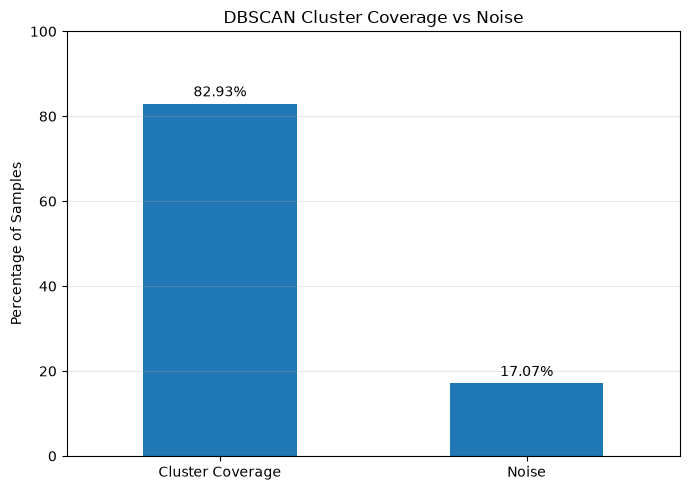

In [ ]:
# Count clustered and noise points

# Number of clustered and noise samples
clustered_samples = np.sum(best_clusters != -1)
noise_samples = np.sum(best_clusters == -1)

total_samples = len(best_clusters)

# Convert to percentages
coverage_percentage = (clustered_samples / total_samples) * 100
noise_percentage = (noise_samples / total_samples) * 100

print("Cluster Coverage:", round(coverage_percentage, 2), "%")
print("Noise Percentage:", round(noise_percentage, 2),"%")


# Graph
coverage_results = pd.DataFrame({
    "Category": [
        "Cluster Coverage",
        "Noise"
    ],
    "Percentage": [
        coverage_percentage,
        noise_percentage
    ]
})

ax = coverage_results.plot(
    x="Category",
    y="Percentage",
    kind="bar",
    figsize=(7, 5),
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("DBSCAN Cluster Coverage vs Noise")
plt.xlabel("")
plt.ylabel("Percentage of Samples")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Spam data plot before DBSCAN

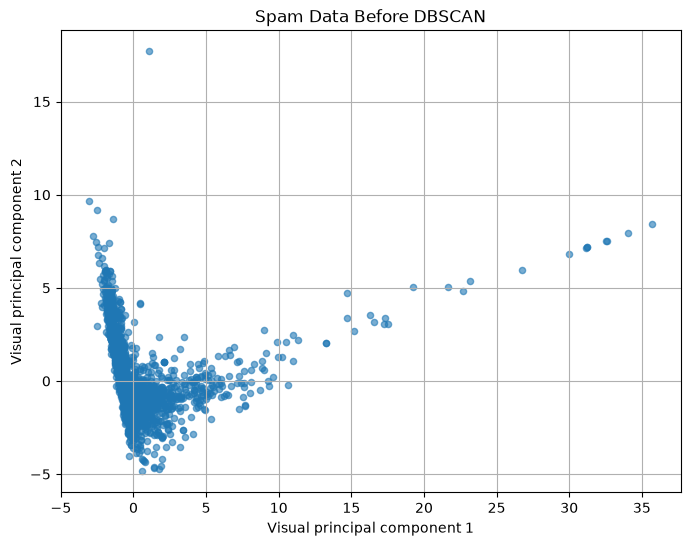

In [109]:
visual_pca = PCA(
    n_components=2,
    random_state=42
)

X_train_plot = visual_pca.fit_transform(
    X_train_pca
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_plot[:, 0],
    X_train_plot[:, 1],
    s=20,
    alpha=0.6
)

plt.xlabel("Visual principal component 1")
plt.ylabel("Visual principal component 2")
plt.title("Spam Data Before DBSCAN")
plt.grid(True)
plt.show()

### Spam data plot after DBSCAN

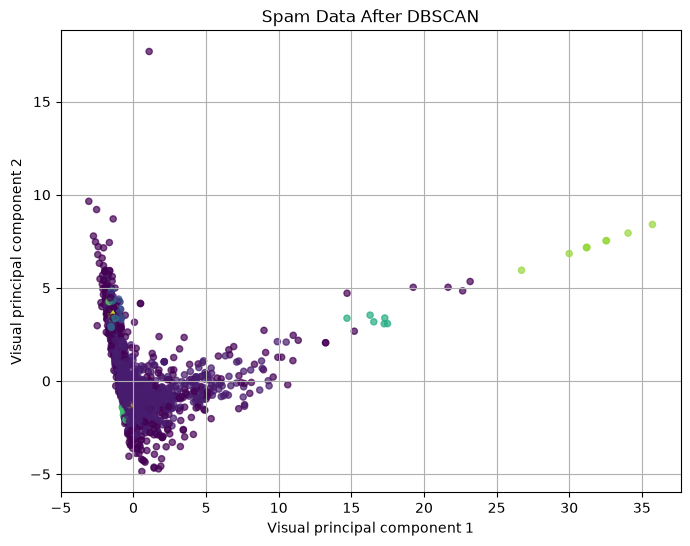

In [110]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_plot[:, 0],
    X_train_plot[:, 1],
    c=best_clusters,
    s=20,
    alpha=0.7
)

plt.xlabel("Visual principal component 1")
plt.ylabel("Visual principal component 2")
plt.title("Spam Data After DBSCAN")
plt.grid(True)
plt.show()

### KPIs

In [113]:
cluster_mapping = {}

y_train_array = np.asarray(y_train)

for cluster in np.unique(best_clusters):

    if cluster == -1:
        continue

    cluster_indices = np.where(best_clusters == cluster)[0]
    majority_class = np.bincount(y_train_array[cluster_indices].astype(int)).argmax()
    cluster_mapping[cluster] = majority_class

print("Cluster mapping:", cluster_mapping)

non_noise_mask = best_clusters != -1
mapped_predictions = np.array([cluster_mapping[cluster] for cluster in best_clusters[non_noise_mask]])
actual_non_noise = y_train_array[non_noise_mask]

print("Accuracy on non-noise records:", accuracy_score(actual_non_noise, mapped_predictions))

# Remove noise points
X_non_noise = X_train_pca[non_noise_mask]
clusters_non_noise = best_clusters[non_noise_mask]

# Silhouette score requires at least 2 clusters
if len(np.unique(clusters_non_noise)) > 1:

    dbscan_silhouette = silhouette_score(
        X_non_noise,
        clusters_non_noise
    )

    print("DBSCAN Silhouette Score:", dbscan_silhouette)

else:
    dbscan_silhouette = np.nan
    print("Silhouette Score cannot be calculated (only one cluster found).")

dbscan_ari = adjusted_rand_score(y_train, best_clusters)
print("Adjusted Rand Index:", dbscan_ari)

dbscan_nmi = normalized_mutual_info_score(y_train, best_clusters)
print("Normalized Mutual Information:", dbscan_nmi)

print("Percentage evaluated:", non_noise_mask.mean() * 100)


print(
    classification_report(
        actual_non_noise,
        mapped_predictions,
        target_names=[
            "Not Spam",
            "Spam"
        ],
        zero_division=0
    )
)


Cluster mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(3): np.int64(1), np.int64(4): np.int64(1), np.int64(5): np.int64(1), np.int64(6): np.int64(0), np.int64(7): np.int64(0), np.int64(8): np.int64(0), np.int64(9): np.int64(1), np.int64(10): np.int64(0), np.int64(11): np.int64(1), np.int64(12): np.int64(0)}
Accuracy on non-noise records: 0.6297887576083064
DBSCAN Silhouette Score: 0.25599653578204373
Adjusted Rand Index: 0.017275645759411824
Normalized Mutual Information: 0.03175813094778732
Percentage evaluated: 82.92755344418052
              precision    recall  f1-score   support

    Not Spam       0.62      1.00      0.77      1707
        Spam       1.00      0.05      0.09      1086

    accuracy                           0.63      2793
   macro avg       0.81      0.52      0.43      2793
weighted avg       0.77      0.63      0.50      2793



## Kmean Clustering

### KMeans Silhouette Score Function

In [57]:
def kmeans_silhouette_score(
    estimator,
    X
):

    labels = estimator.predict(X)

    if len(np.unique(labels)) < 2:
        return -1

    return silhouette_score(
        X,
        labels
    )

### Elbow Method for Kmeans best Hyper parameter finding

Best number of clusters: 7


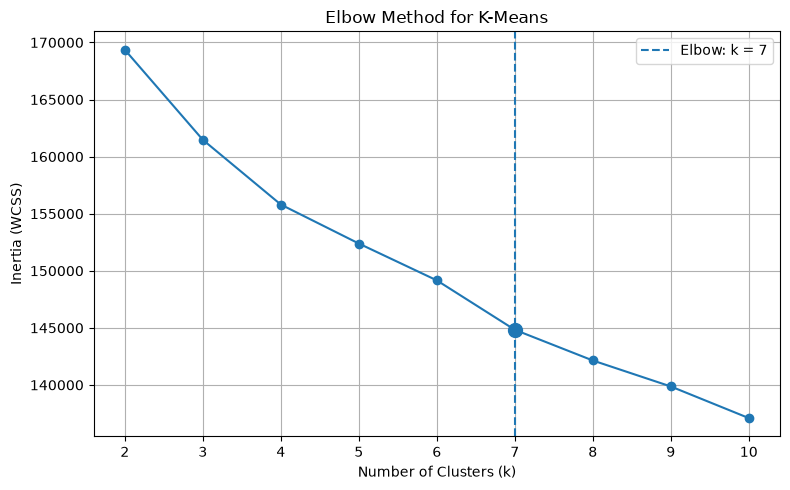

In [58]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(2, 11)
inertia_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_train_pca)

    inertia_values.append(
        kmeans.inertia_
    )

from kneed import KneeLocator

knee = KneeLocator(
    list(k_values),
    inertia_values,
    curve="convex",
    direction="decreasing"
)

best_k = knee.elbow

print(
    "Best number of clusters:",
    best_k
)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

if best_k is not None:

    best_inertia = inertia_values[
        list(k_values).index(best_k)
    ]

    plt.scatter(
        best_k,
        best_inertia,
        s=100,
        zorder=5
    )

    plt.axvline(
        best_k,
        linestyle="--",
        label=f"Elbow: k = {best_k}"
    )

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Training

In [59]:
best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

best_kmeans_clusters = (
    best_kmeans.fit_predict(
        X_train_pca
    )
)

print(
    "Selected number of clusters:",
    best_k
)

Selected number of clusters: 7


### Best Parameters

In [60]:
# Train final KMeans using best k from Elbow Method
best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

best_kmeans.fit(
    X_train_pca
)

print(
    "Best number of clusters:",
    best_k
)


# -----------------------------------
# Training cluster assignments
# -----------------------------------

train_clusters = best_kmeans.predict(
    X_train_pca
)

cluster_mapping = {}

y_train_array = np.asarray(
    y_train
)


# Map each cluster to majority class
for cluster in np.unique(
    train_clusters
):

    cluster_indices = np.where(
        train_clusters == cluster
    )[0]

    majority_class = np.bincount(
        y_train_array[
            cluster_indices
        ].astype(int)
    ).argmax()

    cluster_mapping[
        cluster
    ] = majority_class


print(
    "Cluster Mapping:",
    cluster_mapping
)


# -----------------------------------
# Test cluster assignments
# -----------------------------------

test_clusters = best_kmeans.predict(
    X_test_pca
)


# Convert cluster IDs into Spam / Not Spam
y_pred_kmeans = np.array([
    cluster_mapping[
        cluster
    ]
    for cluster in test_clusters
])


print(
    "Predicted classes:",
    np.unique(
        y_pred_kmeans,
        return_counts=True
    )
)

Best number of clusters: 7
Cluster Mapping: {np.int32(0): np.int64(1), np.int32(1): np.int64(0), np.int32(2): np.int64(1), np.int32(3): np.int64(0), np.int32(4): np.int64(1), np.int32(5): np.int64(1), np.int32(6): np.int64(0)}
Predicted classes: (array([0, 1]), array([510, 332]))


### KPIs

Accuracy: 0.8669833729216152
Adjusted Rand Index: 0.3459059662322143
Normalized Mutual Information: 0.32741587944993517
Silhouette Score: 0.03354539247899878


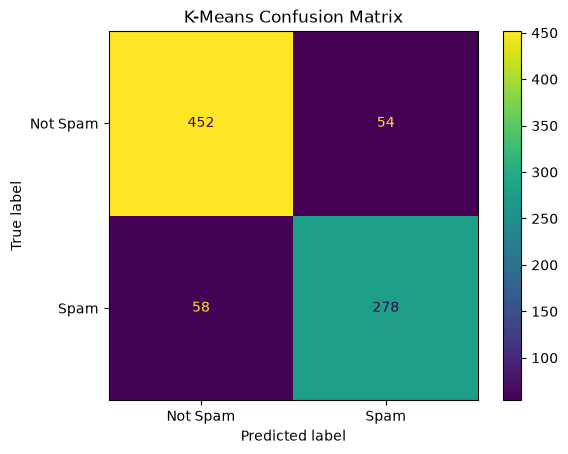

In [61]:
print("Accuracy:",
    accuracy_score(
        y_test,
        y_pred_kmeans
    )
)

kmeans_ari = adjusted_rand_score(
    y_test,
    test_clusters
)

kmeans_nmi = normalized_mutual_info_score(
    y_test,
    test_clusters
)

kmeans_silhouette = silhouette_score(
    X_test_pca,
    test_clusters
)

print(
    "Adjusted Rand Index:",
    kmeans_ari
)

print(
    "Normalized Mutual Information:",
    kmeans_nmi
)

print(
    "Silhouette Score:",
    kmeans_silhouette
)

cm = confusion_matrix(
    y_test,
    y_pred_kmeans
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Spam",
        "Spam"
    ]
).plot()

plt.title(
    "K-Means Confusion Matrix"
)

plt.show()

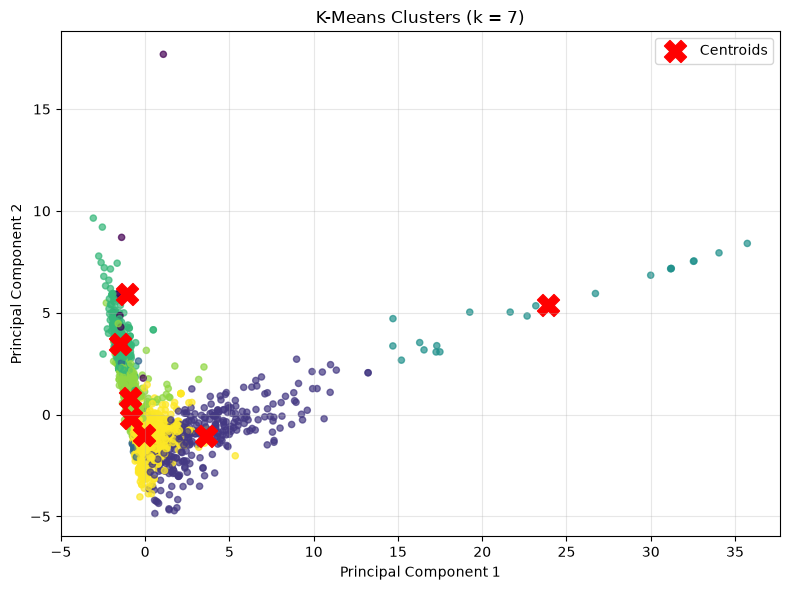

In [62]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Reduce PCA data to 2 dimensions for plotting
plot_pca = PCA(
    n_components=2,
    random_state=42
)

X_plot = plot_pca.fit_transform(
    X_train_pca
)


# Transform K-Means centroids into same 2D space
centers_plot = plot_pca.transform(
    best_kmeans.cluster_centers_
)


plt.figure(figsize=(8, 6))


# Plot clustered samples
scatter = plt.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    c=train_clusters,
    cmap="viridis",
    s=20,
    alpha=0.7
)


# Plot centroids
plt.scatter(
    centers_plot[:, 0],
    centers_plot[:, 1],
    marker="X",
    s=250,
    c="red",
    label="Centroids"
)


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    f"K-Means Clusters (k = {best_k})"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Deep Learning

### Confirming Data Shape

In [63]:
# !pip install keras
# !pip install tensorflow

import keras
from keras import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping

print("Training features:", X_train_pca.shape)
print("Testing features:", X_test_pca.shape)
print("Training labels:", np.asarray(y_train).shape)
print("Testing labels:", np.asarray(y_test).shape)

Training features: (3368, 48)
Testing features: (842, 48)
Training labels: (3368,)
Testing labels: (842,)


### Converting Labels and Features into Arrays

In [64]:
y_train_nn = np.asarray(y_train).astype("float32")
y_test_nn = np.asarray(y_test).astype("float32")
X_train_nn = np.asarray(X_train_pca).astype("float32")
X_test_nn = np.asarray(X_test_pca).astype("float32")

### Create the neural network

In [65]:
mlp_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

### Compiling and Training the model

In [66]:
mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = mlp_model.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6815 - auc: 0.6862 - loss: 0.6254 - precision: 0.7039 - recall: 0.3277 - val_accuracy: 0.8427 - val_auc: 0.9318 - val_loss: 0.4585 - val_precision: 0.9588 - val_recall: 0.6549
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8497 - auc: 0.9140 - loss: 0.3854 - precision: 0.8699 - recall: 0.7262 - val_accuracy: 0.9080 - val_auc: 0.9659 - val_loss: 0.2552 - val_precision: 0.9405 - val_recall: 0.8345
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8964 - auc: 0.9435 - loss: 0.2949 - precision: 0.8861 - recall: 0.8451 - val_accuracy: 0.9288 - val_auc: 0.9718 - val_loss: 0.2163 - val_precision: 0.9338 - val_recall: 0.8944
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9076 - auc: 0.9569 - loss: 0.2602 - precision: 0.9116 - recall: 0.8470 - val_accuracy: 0.9347 - val_auc: 0.9742 - val_loss: 0.2050 - val_precision: 0.9317 - val_recall: 0.9120
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s

### Graph of Training and Validation loss

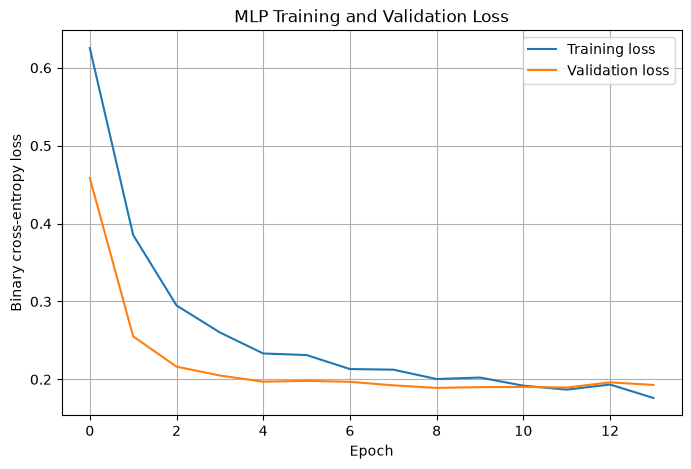

In [67]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Graph of Training and Validation accuracy

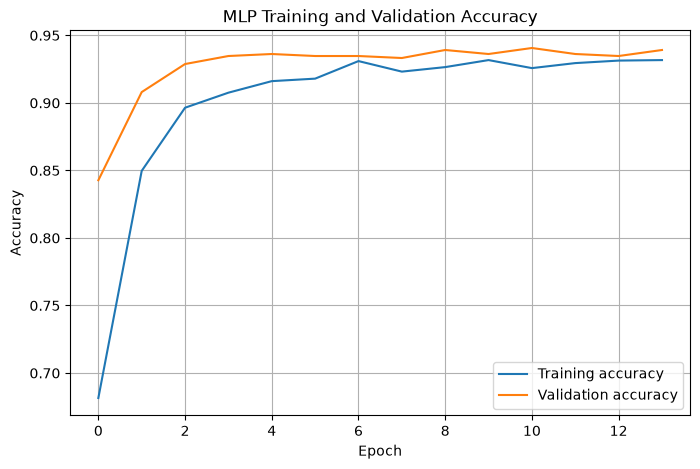

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation on the test set

In [69]:
test_results = mlp_model.evaluate(
    X_test_nn,
    y_test_nn,
    verbose=0
)

for metric_name, metric_value in zip(
    mlp_model.metrics_names,
    test_results
):
    print(f"{metric_name}: {metric_value:.4f}")

loss: 0.1841
compile_metrics: 0.9311


### KPIs

MLP test accuracy: 0.9311163895486936
              precision    recall  f1-score   support

    Not Spam       0.94      0.94      0.94       506
        Spam       0.91      0.91      0.91       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842



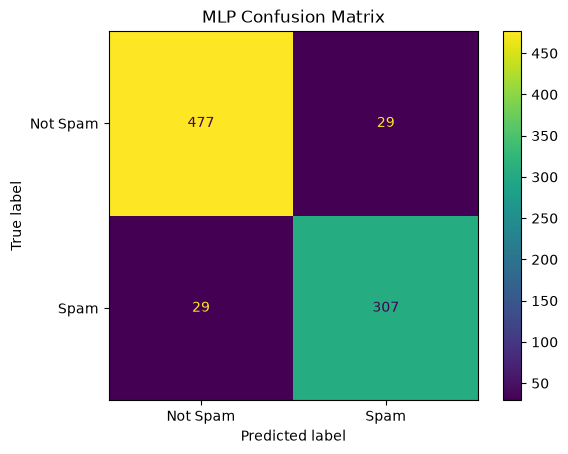

MLP ROC-AUC: 0.9787608225108225


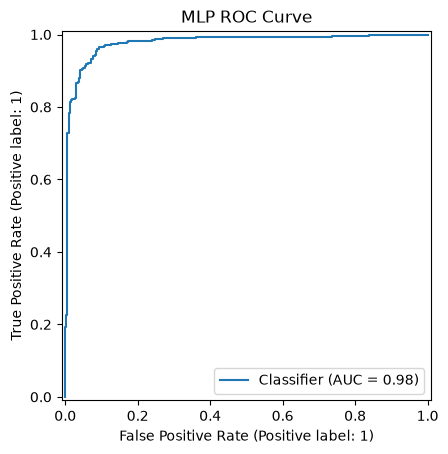

In [70]:
y_probability_mlp = mlp_model.predict(
    X_test_nn,
    verbose=0
).ravel()

y_pred_mlp = (
    y_probability_mlp >= 0.50
).astype(int)

KPIs(y_test, y_pred_mlp, y_probability_mlp, "MLP")

### Check for overfitting

In [71]:
final_training_accuracy = history.history[
    "accuracy"
][-1]

final_validation_accuracy = history.history[
    "val_accuracy"
][-1]

print(
    "Final training accuracy:",
    final_training_accuracy
)

print(
    "Final validation accuracy:",
    final_validation_accuracy
)

print(
    "Difference:",
    final_training_accuracy -
    final_validation_accuracy
)

best_epoch = np.argmin(
    history.history["val_loss"]
) + 1

print("Best epoch:", best_epoch)

print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

print(
    "Validation accuracy at best epoch:",
    history.history["val_accuracy"][
        best_epoch - 1
    ]
)

Final training accuracy: 0.9317000508308411
Final validation accuracy: 0.93916916847229
Difference: -0.007469117641448975
Best epoch: 9
Best validation loss: 0.18901288509368896
Validation accuracy at best epoch: 0.93916916847229


## Autoencoder

### Convert the data to NumPy arrays

In [72]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
import tensorflow as tf

X_train_auto = np.asarray(X_train_pca).astype("float32")
X_test_auto = np.asarray(X_test_pca).astype("float32")

y_train_auto = np.asarray(y_train).astype(int)
y_test_auto = np.asarray(y_test).astype(int)

print("Training features:", X_train_auto.shape)
print("Testing features:", X_test_auto.shape)
print("Training labels:", y_train_auto.shape)
print("Testing labels:", y_test_auto.shape)

Training features: (3368, 48)
Testing features: (842, 48)
Training labels: (3368,)
Testing labels: (842,)


### Create training and validation sets

In [73]:
X_train_normal = X_train_auto[
    y_train_auto == 0
]

print("Normal training samples:", X_train_normal.shape)

X_normal_train, X_normal_validation = train_test_split(
    X_train_normal,
    test_size=0.20,
    random_state=42
)

print("Autoencoder training set:", X_normal_train.shape)
print("Autoencoder validation set:", X_normal_validation.shape)

Normal training samples: (2025, 48)
Autoencoder training set: (1620, 48)
Autoencoder validation set: (405, 48)


### Creating the Autoencoder

In [74]:
number_of_features = X_normal_train.shape[1]

autoencoder = Sequential([
    Input(shape=(number_of_features,)),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.10),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        8,
        activation="relu",
        name="bottleneck"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        number_of_features,
        activation="linear"
    )
])

### Compile and Training

In [75]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_autoencoder = autoencoder.fit(
    X_normal_train,
    X_normal_train,
    validation_data=(
        X_normal_validation,
        X_normal_validation
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 48)             │         1,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,504 (17.59 KB)

 Trainable params: 4,504 (17.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2167 - val_loss: 0.8837
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1560 - val_loss: 0.8373
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0482 - val_loss: 0.7794
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9556 - val_loss: 0.7460
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9121 - val_loss: 0.7254
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8780 - val_loss: 0.7029
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8551 - val_loss: 0.6887
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8316 - val_loss: 0.6722
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8130 - val_loss: 0.6568
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7891 - val_loss: 0.6410
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7777 - val_loss: 0.6270
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7

### Training and Validation loss Graph

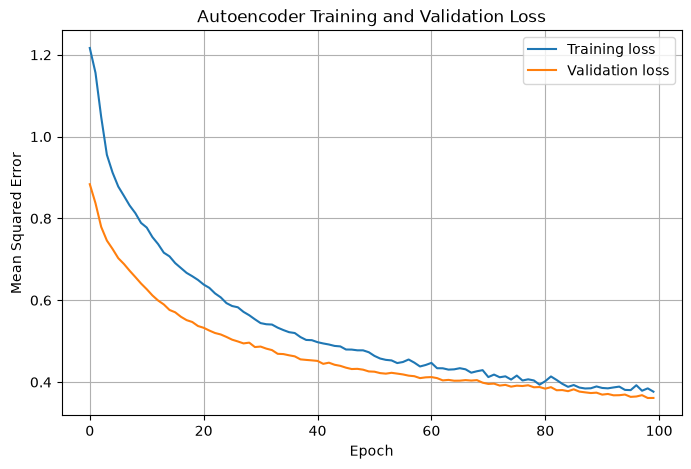

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_autoencoder.history["loss"],
    label="Training loss"
)

plt.plot(
    history_autoencoder.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Reconstruction Error Graph

Mean validation reconstruction error: 0.36108652
Maximum validation reconstruction error: 13.123822
Reconstruction-error threshold: 1.105004


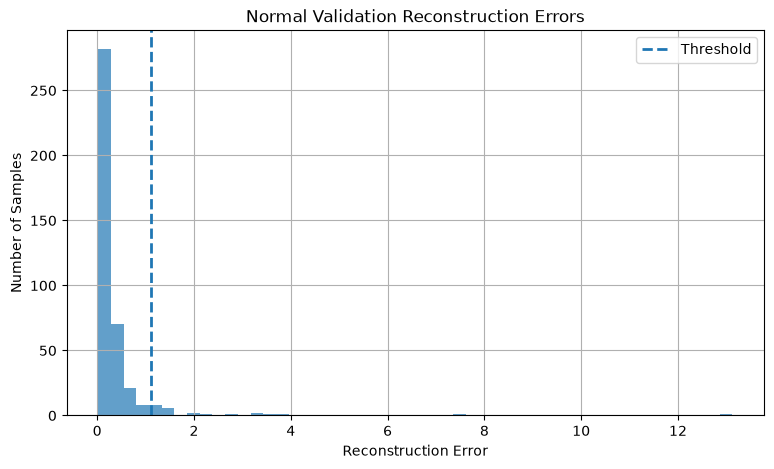

In [77]:
validation_reconstructed = autoencoder.predict(
    X_normal_validation,
    verbose=0
)

validation_errors = np.mean(
    np.square(
        X_normal_validation -
        validation_reconstructed
    ),
    axis=1
)

print("Mean validation reconstruction error:", validation_errors.mean())
print("Maximum validation reconstruction error:", validation_errors.max())

threshold = np.percentile(
    validation_errors,
    95
)

print("Reconstruction-error threshold:", threshold)

plt.figure(figsize=(9, 5))

plt.hist(
    validation_errors,
    bins=50,
    alpha=0.7
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Normal Validation Reconstruction Errors")
plt.legend()
plt.grid(True)
plt.show()

### KPIs

Autoencoder test accuracy: 0.6603325415676959
              precision    recall  f1-score   support

    Not Spam       0.65      0.95      0.77       506
        Spam       0.74      0.23      0.35       336

    accuracy                           0.66       842
   macro avg       0.69      0.59      0.56       842
weighted avg       0.69      0.66      0.60       842



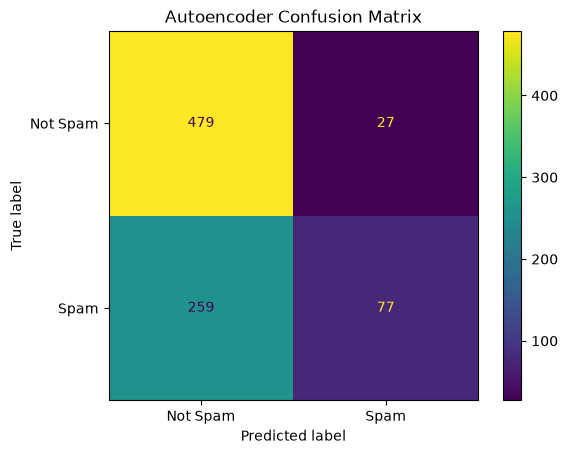

Autoencoder ROC-AUC: 0.7325781102955016


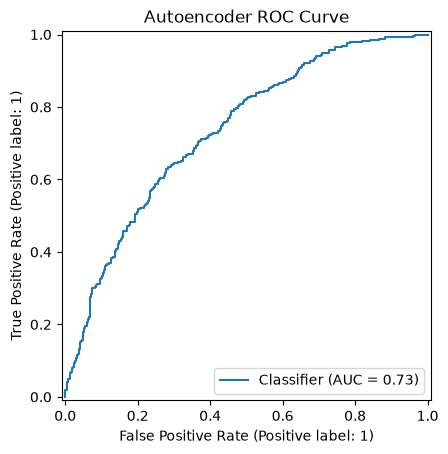

In [78]:
X_test_reconstructed = autoencoder.predict(
    X_test_auto,
    verbose=0
)

test_reconstruction_errors = np.mean(
    np.square(
        X_test_auto -
        X_test_reconstructed
    ),
    axis=1
)

y_pred_autoencoder = (
    test_reconstruction_errors > threshold
).astype(int)

y_probability_auto = np.mean(
    np.abs(X_test_pca - X_test_reconstructed),
    axis=1
)

KPIs(y_test, y_pred_autoencoder, y_probability_auto, "Autoencoder")

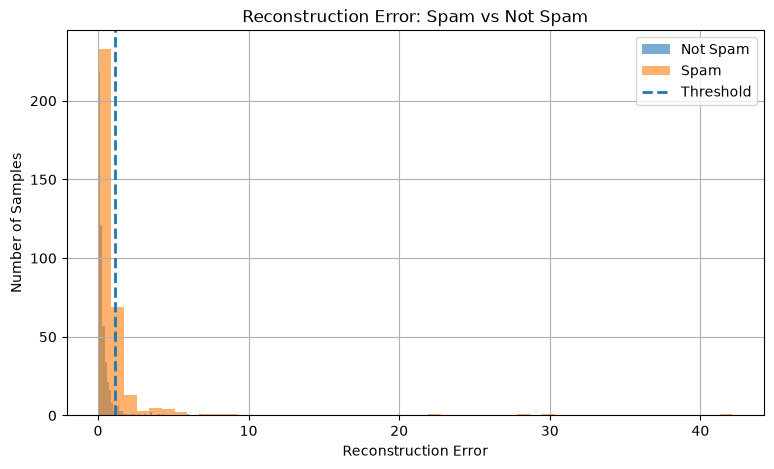

In [79]:
error_dataframe = pd.DataFrame({
    "Reconstruction Error": test_reconstruction_errors,
    "Actual Label": y_test_auto
})

not_spam_errors = error_dataframe[
    error_dataframe["Actual Label"] == 0
]["Reconstruction Error"]

spam_errors = error_dataframe[
    error_dataframe["Actual Label"] == 1
]["Reconstruction Error"]

plt.figure(figsize=(9, 5))

plt.hist(
    not_spam_errors,
    bins=50,
    alpha=0.6,
    label="Not Spam"
)

plt.hist(
    spam_errors,
    bins=50,
    alpha=0.6,
    label="Spam"
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Reconstruction Error: Spam vs Not Spam")
plt.legend()
plt.grid(True)
plt.show()

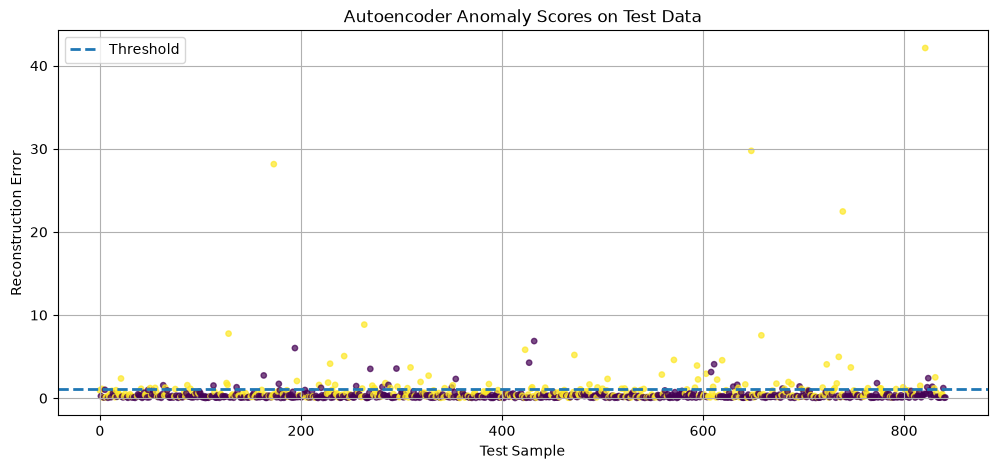

In [80]:
plt.figure(figsize=(12, 5))

plt.scatter(
    range(len(test_reconstruction_errors)),
    test_reconstruction_errors,
    c=y_test_auto,
    s=15,
    alpha=0.7
)

plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Test Sample")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Anomaly Scores on Test Data")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
threshold_percentiles = [
    90,
    92,
    95,
    97,
    99
]

threshold_results = []

for percentile in threshold_percentiles:

    current_threshold = np.percentile(
        validation_errors,
        percentile
    )

    current_predictions = (
        test_reconstruction_errors >
        current_threshold
    ).astype(int)

    report = classification_report(
        y_test_auto,
        current_predictions,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )

    threshold_results.append({
        "Percentile": percentile,
        "Threshold": current_threshold,
        "Accuracy": accuracy_score(
            y_test_auto,
            current_predictions
        ),
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    })

threshold_results = pd.DataFrame(
    threshold_results
)

print(threshold_results)

   Percentile  Threshold  Accuracy  Spam Precision  Spam Recall   Spam F1
0          90   0.666795  0.691211        0.702128     0.392857  0.503817
1          92   0.791915  0.684086        0.724359     0.336310  0.459350
2          95   1.105004  0.660333        0.740385     0.229167  0.350000
3          97   1.430409  0.634204        0.725806     0.133929  0.226131
4          99   3.393423  0.615202        0.750000     0.053571  0.100000


# Summary

In [82]:
def calculate_model_metrics(
    model_name,
    model_type,
    y_true,
    y_pred,
    y_score=None
):
    """
    Calculates binary spam-detection metrics.

    y_score should contain probabilities or anomaly scores.
    It is optional because some models do not provide them.
    """

    results = {
        "Model": model_name,
        "Category": model_type,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Spam Precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "Spam Recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "Spam F1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    }

    if y_score is not None:
        results["ROC-AUC"] = roc_auc_score(
            y_true,
            y_score
        )
    else:
        results["ROC-AUC"] = np.nan

    return results

In [83]:
# KNN
y_test_pred

# Logistic Regression
y_pred_logistic
y_prob_logistic

# GMM
y_pred_gmm

# DBSCAN, after excluding noise
actual_non_noise
mapped_predictions

# MLP
y_pred_mlp
y_probability_mlp

# Autoencoder
y_pred_autoencoder
test_reconstruction_errors

array([9.45287228e-01, 2.47406587e-01, 1.11806595e+00, 8.04641619e-02,
       7.91054592e-02, 1.01088619e+00, 1.09953731e-01, 1.87170327e-01,
       4.89064455e-02, 2.36850336e-01, 4.69082505e-01, 1.10085852e-01,
       8.79989624e-01, 5.78495264e-01, 3.83260816e-01, 1.20662481e-01,
       9.60610449e-01, 1.67623281e-01, 6.63436651e-01, 4.83660221e-01,
       2.35840604e-01, 2.36729455e+00, 1.95563316e-01, 9.16523561e-02,
       1.90577924e-01, 5.18921196e-01, 1.91677198e-01, 1.24357313e-01,
       5.06882854e-02, 2.90836930e-01, 4.66210753e-01, 1.74617872e-01,
       7.58424997e-02, 1.87431976e-01, 1.02066197e-01, 3.99128161e-02,
       1.68143392e-01, 2.42877141e-01, 4.81110662e-01, 3.50543231e-01,
       1.87309816e-01, 1.13334846e+00, 4.53457087e-02, 1.49765179e-01,
       6.57858610e-01, 3.73735428e-01, 4.96178716e-01, 9.03099179e-02,
       9.90349591e-01, 9.57723632e-02, 1.21415937e+00, 3.17276388e-01,
       4.92385000e-01, 9.29856956e-01, 3.05720210e-01, 1.23792648e+00,
      

In [84]:
y_probability_knn = best_knn.predict_proba(
    X_test_pca
)[:, 1]

all_model_results = []

all_model_results.append(
    calculate_model_metrics(
        model_name="KNN",
        model_type="Supervised",
        y_true=y_test,
        y_pred=y_test_pred,
        y_score=y_probability_knn
    )
)

all_model_results.append(
    calculate_model_metrics(
        model_name="Logistic Regression",
        model_type="Supervised",
        y_true=y_test,
        y_pred=y_pred_logistic,
        y_score=y_prob_logistic
    )
)

all_model_results.append(
    calculate_model_metrics(
        model_name="Random Forest",
        model_type="Supervised",
        y_true=y_test,
        y_pred=y_pred_random_forest,
        y_score=y_probability_random_forest
    )
)



all_model_results.append(
    calculate_model_metrics(
        model_name="MLP",
        model_type="Deep Learning",
        y_true=y_test_nn.astype(int),
        y_pred=y_pred_mlp,
        y_score=y_probability_mlp
    )
)

all_model_results.append(
    calculate_model_metrics(
        model_name="Autoencoder",
        model_type="Deep Learning",
        y_true=y_test_auto,
        y_pred=y_pred_autoencoder,
        y_score=test_reconstruction_errors
    )
)

model_comparison = pd.DataFrame(
    all_model_results
)

metric_columns = [
    "Accuracy",
    "Spam Precision",
    "Spam Recall",
    "Spam F1",
    "ROC-AUC"
]

model_comparison[metric_columns] = (
    model_comparison[metric_columns].round(4)
)

model_comparison

,Model,Category,Accuracy,Spam Precision,Spam Recall,Spam F1,ROC-AUC
0,KNN,Supervised,0.9086,0.8648,0.9137,0.8886,0.9617
1,Logistic Regression,Supervised,0.8943,0.8601,0.8780,0.8689,0.9501
2,Random Forest,Supervised,0.9406,0.9231,0.9286,0.9258,0.9897
3,MLP,Deep Learning,0.9311,0.9137,0.9137,0.9137,0.9788
4,Autoencoder,Deep Learning,0.6603,0.7404,0.2292,0.3500,0.7363


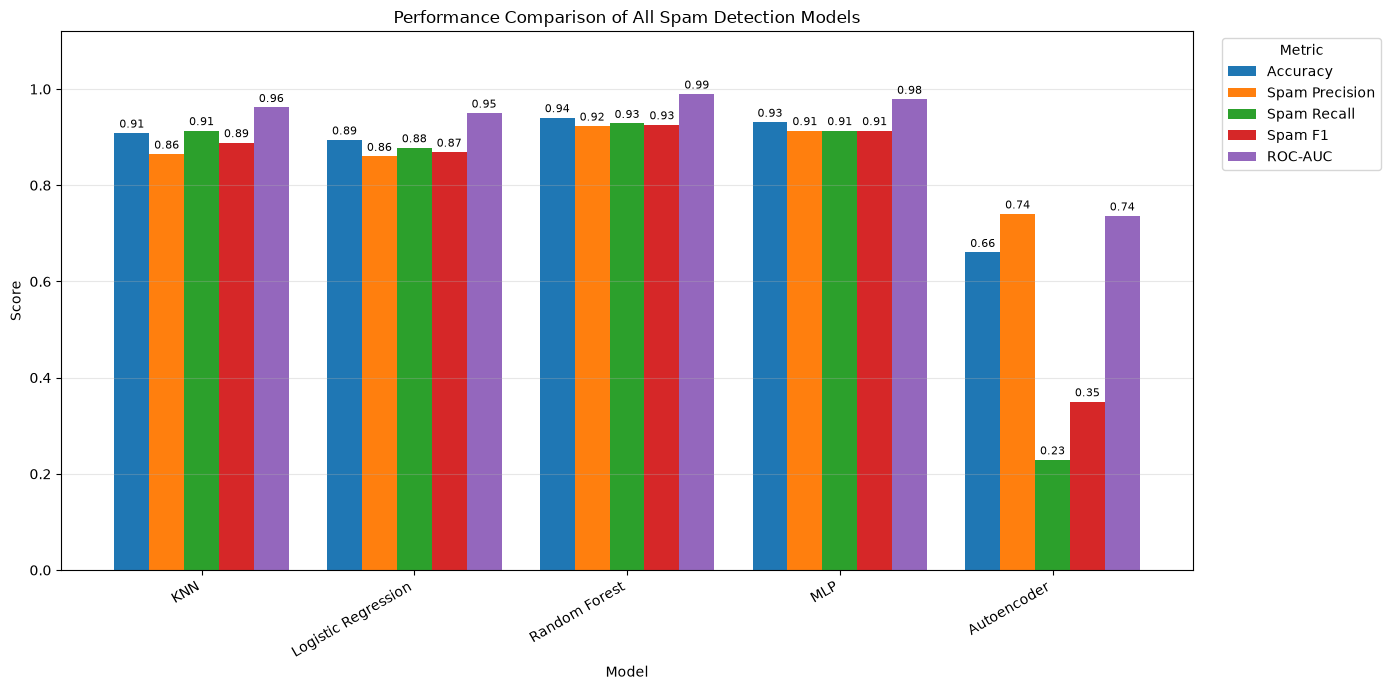

In [85]:
plot_data = model_comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Spam Precision",
        "Spam Recall",
        "Spam F1",
        "ROC-AUC"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=8,
        padding=2
    )

plt.title(
    "Performance Comparison of All Spam Detection Models"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.12)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

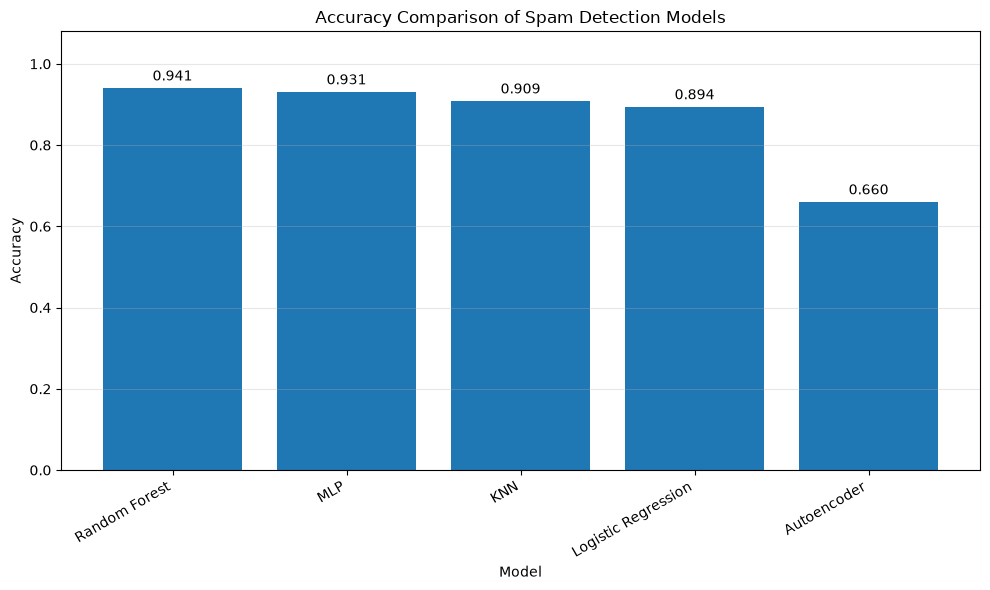

In [86]:
accuracy_results = model_comparison.sort_values(
    "Accuracy",
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    accuracy_results["Model"],
    accuracy_results["Accuracy"]
)

plt.bar_label(
    bars,
    fmt="%.3f",
    padding=3
)

plt.title(
    "Accuracy Comparison of Spam Detection Models"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.08)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

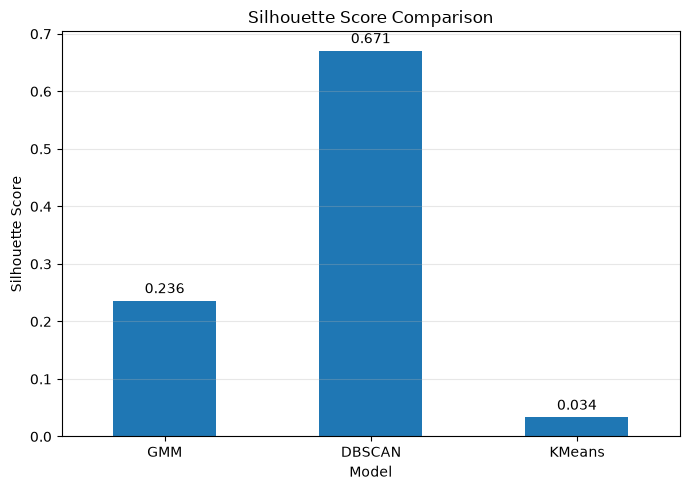

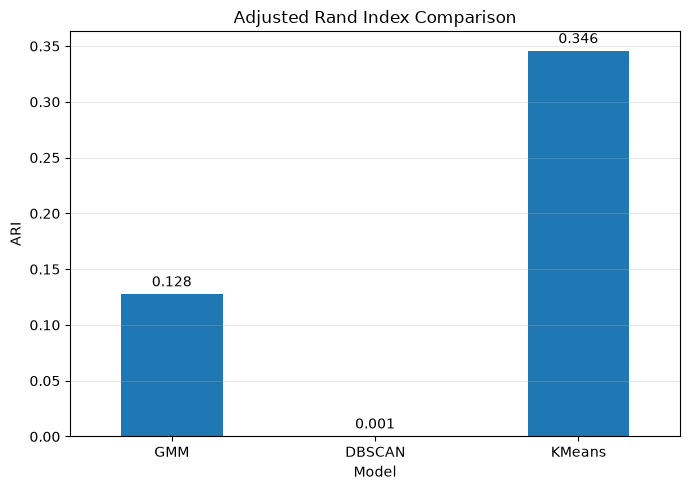

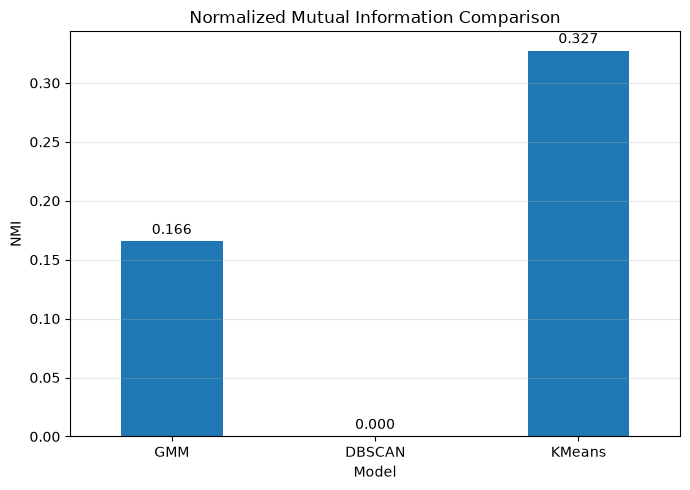

In [87]:
dbscan_coverage = (
    len(actual_non_noise) /
    len(y_train)
)

unsupervised_results = pd.DataFrame({
    "Model": [
        "GMM",
        "DBSCAN",
        "KMeans"
    ],

    "Silhouette Score": [
        gmm_silhouette_score,
        dbscan_silhouette,
        kmeans_silhouette
    ],

    "Adjusted Rand Index": [
        gmm_ari,
        dbscan_ari,
        kmeans_ari
    ],

    "Normalized Mutual Information": [
        gmm_nmi,
        dbscan_nmi,
        kmeans_nmi
    ],

    "Coverage": [
        1.0,
        dbscan_coverage,
        1.0
    ]
})

metric_columns = [
    "Silhouette Score",
    "Adjusted Rand Index",
    "Normalized Mutual Information",
    "Coverage"
]

for column in metric_columns:
    unsupervised_results[column] = pd.to_numeric(
        unsupervised_results[column],
        errors="coerce"
    )
    
def plot_metric(metric_name, y_label):

    ax = unsupervised_results.plot(
        x="Model",
        y=metric_name,
        kind="bar",
        figsize=(7, 5),
        legend=False
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3
        )

    plt.title(f"{metric_name} Comparison")
    plt.xlabel("Model")
    plt.ylabel(y_label)
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric("Silhouette Score", "Silhouette Score")
plot_metric("Adjusted Rand Index","ARI")
plot_metric("Normalized Mutual Information","NMI")